# Stage 3: Fully MPS-Native LBM

Demonstrates the complete "never decompress" workflow:
- Simulate, extract observables, check convergence — all in MPS space.

### Sections
1. Fair BC Comparison (HWBB vs FWBB vs MPS-native)
2. MPS-Native Observables Validation
3. Coarse Field Extraction
4. End-to-End MPS-Native Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk, apply_fwbb
from lbm.boundary import apply_bounce_back, apply_bounce_back_moving_top
from lbm.collision import compute_moments
from simulations.lid_driven_cavity import (
    create_cavity_walls, GHIA_Y, GHIA_U_RE100
)
from tn.compression import compress_populations, decompress_populations
from tn_lbm.collision import collide_bgk_mps
from tn_lbm.boundary import precompute_cavity_bc, apply_mps_boundary
from tn_lbm.observables import (
    mps_evaluate_at_point, mps_coarse_field,
    compute_drag_lift_mps, check_convergence_mps
)
from tn_lbm.boundary import mask_to_mps

print("All modules loaded successfully")

All modules loaded successfully


## 1. Fair BC Comparison

Three approaches, all on the same cavity problem:
- **Vanilla HWBB**: standard post-streaming bounce-back (wall at half-cell)
- **Vanilla FWBB**: full-way bounce-back with non-cyclic streaming (wall on-node)
- **MPS-native**: fully compressed FWBB (collision + streaming + BC in MPS)

HWBB vs FWBB are both standard LBM variants (Kruger et al. 2017, Ch. 5.3).
FWBB is the dense equivalent of what MPS-native does. So: vanilla-FWBB vs MPS-native isolates the compression effect.

In [ ]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])
mapping = 'snake'
max_nt = 15000; conv_tol = 1e-6
initial_mass = float(n * n)

# --- Run vanilla HWBB to convergence (L2 norm, 2 consecutive) ---
print("Running vanilla HWBB...")
f_hwbb = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
u_prev = np.zeros((2,n,n)); consec = 0; t_conv = max_nt
mass_hwbb_hist = {'t': [], 'mass': [], 'rel_drift': []}

for t in range(max_nt):
    f_hwbb = collide_bgk(D2Q9, f_hwbb, tau)
    f_hwbb = stream(D2Q9, f_hwbb)
    f_hwbb = apply_bounce_back(D2Q9, f_hwbb, walls)
    f_hwbb = apply_bounce_back_moving_top(D2Q9, f_hwbb, u_wall)
    _, u_v = compute_moments(D2Q9, f_hwbb)
    du = np.sqrt(np.sum((u_v - u_prev)**2) / (np.sum(u_v**2) + 1e-30))
    u_prev = u_v.copy()
    consec = consec + 1 if (t > 0 and du < conv_tol) else 0
    if t % 200 == 0:
        m = np.sum(compute_moments(D2Q9, f_hwbb)[0])
        mass_hwbb_hist['t'].append(t)
        mass_hwbb_hist['mass'].append(m)
        mass_hwbb_hist['rel_drift'].append((m - initial_mass) / initial_mass)
    if consec >= 2:
        t_conv = t; print(f"  Converged at t={t} (du={du:.2e})"); break
    if t % 2000 == 0: print(f"  t={t}, du={du:.2e}")

# --- Run vanilla FWBB for same steps ---
print(f"\nRunning vanilla FWBB for {t_conv} steps...")
f_fwbb = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
mass_fwbb_hist = {'t': [], 'mass': [], 'rel_drift': []}
for t in range(t_conv + 1):
    f_fwbb = collide_bgk(D2Q9, f_fwbb, tau)
    f_fwbb = apply_fwbb(D2Q9, f_fwbb, lid, u_wall)
    if t % 200 == 0:
        m = np.sum(compute_moments(D2Q9, f_fwbb)[0])
        mass_fwbb_hist['t'].append(t)
        mass_fwbb_hist['mass'].append(m)
        mass_fwbb_hist['rel_drift'].append((m - initial_mass) / initial_mass)
    if t % 2000 == 0 and t > 0: print(f"  t={t}")
print("  Done.")

# --- Run MPS-native for same steps ---
print(f"\nRunning MPS-native for {t_conv} steps...")
bc_data = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)
f_init = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
mps_list, meta = compress_populations(f_init, mapping=mapping)
mass_mps_hist = {'t': [], 'mass': [], 'rel_drift': []}
t_start = time.time()
for t in range(t_conv + 1):
    mps_list = collide_bgk_mps(mps_list, D2Q9, tau, n, max_bond=64)
    mps_list = apply_mps_boundary(mps_list, D2Q9, bc_data, max_bond=64)
    if t % 200 == 0:
        from tn_lbm.arithmetic import mps_sum_value
        m = sum(mps_sum_value(mps_list[i]) for i in range(9))
        mass_mps_hist['t'].append(t)
        mass_mps_hist['mass'].append(m)
        mass_mps_hist['rel_drift'].append((m - initial_mass) / initial_mass)
    if t % 2000 == 0 and t > 0: print(f"  t={t}")
elapsed = time.time() - t_start
f_mps = decompress_populations(mps_list, meta)
print(f"  Done in {elapsed:.0f}s.")

RMS error vs Ghia (Re=100, 64x64, 7036 steps):
  Vanilla HWBB (standard):  0.045806
  Vanilla FWBB (full-way):  0.022476
  MPS-native:               0.022411
  FWBB vs MPS (compression only): 0.000238


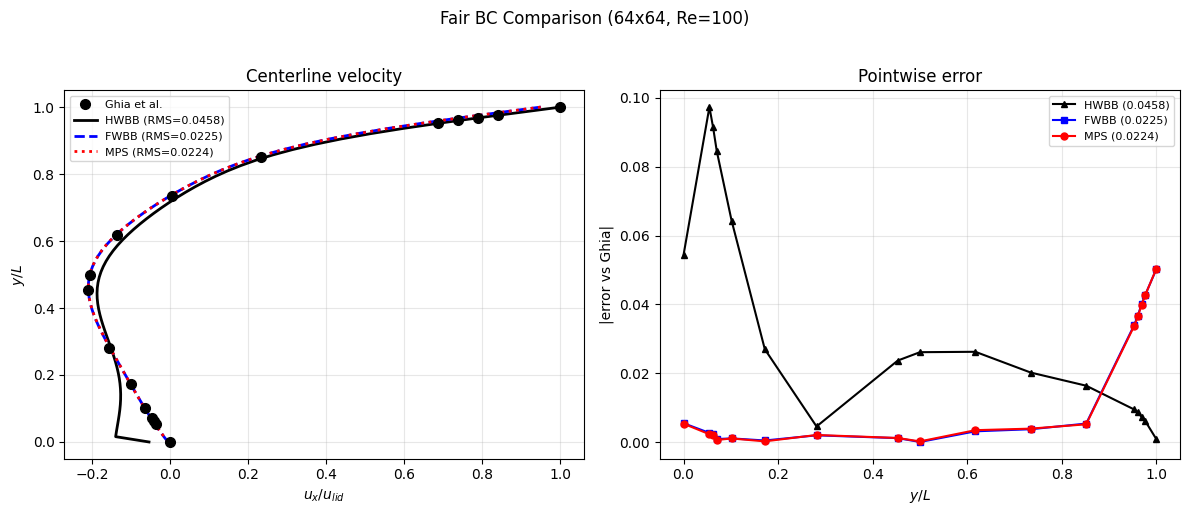

In [3]:
# Compare all three to Ghia
_, u_hwbb = compute_moments(D2Q9, f_hwbb)
_, u_fwbb = compute_moments(D2Q9, f_fwbb)
_, u_mps = compute_moments(D2Q9, f_mps)

mid = n // 2
y_coords = np.linspace(0, 1, n)

ux_hwbb = np.interp(GHIA_Y, y_coords, u_hwbb[0, mid, :] / u_lid)
ux_fwbb = np.interp(GHIA_Y, y_coords, u_fwbb[0, mid, :] / u_lid)
ux_mps = np.interp(GHIA_Y, y_coords, u_mps[0, mid, :] / u_lid)

rms_hwbb = np.sqrt(np.mean((ux_hwbb - GHIA_U_RE100)**2))
rms_fwbb = np.sqrt(np.mean((ux_fwbb - GHIA_U_RE100)**2))
rms_mps = np.sqrt(np.mean((ux_mps - GHIA_U_RE100)**2))

# FWBB vs MPS difference (isolates compression effect)
rms_fwbb_vs_mps = np.sqrt(np.mean((ux_fwbb - ux_mps)**2))

print(f"RMS error vs Ghia (Re={Re}, {n}x{n}, {t_conv} steps):")
print(f"  Vanilla HWBB (standard):  {rms_hwbb:.6f}")
print(f"  Vanilla FWBB (full-way):  {rms_fwbb:.6f}")
print(f"  MPS-native:               {rms_mps:.6f}")
print(f"  FWBB vs MPS (compression only): {rms_fwbb_vs_mps:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(GHIA_U_RE100, GHIA_Y, 'ko', markersize=7, label='Ghia et al.', zorder=5)
ax.plot(u_hwbb[0, mid, :]/u_lid, y_coords, 'k-', linewidth=2, label=f'HWBB (RMS={rms_hwbb:.4f})')
ax.plot(u_fwbb[0, mid, :]/u_lid, y_coords, 'b--', linewidth=2, label=f'FWBB (RMS={rms_fwbb:.4f})')
ax.plot(u_mps[0, mid, :]/u_lid, y_coords, 'r:', linewidth=2, label=f'MPS (RMS={rms_mps:.4f})')
ax.set_xlabel('$u_x / u_{lid}$'); ax.set_ylabel('$y / L$')
ax.set_title('Centerline velocity'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(GHIA_Y, np.abs(ux_hwbb - GHIA_U_RE100), 'k^-', markersize=5, label=f'HWBB ({rms_hwbb:.4f})')
ax.plot(GHIA_Y, np.abs(ux_fwbb - GHIA_U_RE100), 'bs-', markersize=5, label=f'FWBB ({rms_fwbb:.4f})')
ax.plot(GHIA_Y, np.abs(ux_mps - GHIA_U_RE100), 'ro-', markersize=5, label=f'MPS ({rms_mps:.4f})')
ax.set_xlabel('$y / L$'); ax.set_ylabel('|error vs Ghia|')
ax.set_title('Pointwise error'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Fair BC Comparison ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

## 2. MPS-Native Observables Validation

Extract physical quantities directly from MPS — verify against decompressed values.

In [4]:
# Use the converged MPS-native state from Section 1

# --- Point evaluation: centerline velocity at Ghia's y-positions ---
print("Point evaluation: centerline ux at Ghia y-positions")
print("=" * 60)
print(f"{'y/L':>6} | {'MPS point eval':>14} | {'Decompressed':>12} | {'Ghia':>8} | {'pt_err':>8}")
print("-" * 60)

# We need ux = rhou_x / rho. Extract rhou_x and rho at each point.
# Simpler: decompress ONCE for validation, then show point eval matches
_, u_mps_dense = compute_moments(D2Q9, f_mps)  # already have this from Section 1

mid_x = n // 2
max_pt_err = 0
for j, ghia_y in enumerate(GHIA_Y):
    y_idx = int(round(ghia_y * (n - 1)))
    y_idx = min(y_idx, n - 1)
    
    # Point evaluation from MPS (sum c_ix * f_i at this point, divide by sum f_i)
    rho_pt = 0.0
    rhou_x_pt = 0.0
    for i in range(9):
        fi_val = mps_evaluate_at_point(mps_list[i], mid_x, y_idx, n, meta)
        rho_pt += fi_val
        rhou_x_pt += D2Q9.c[i, 0] * fi_val
    ux_mps_pt = rhou_x_pt / rho_pt
    
    ux_dense = u_mps_dense[0, mid_x, y_idx]
    pt_err = abs(ux_mps_pt - ux_dense)
    max_pt_err = max(max_pt_err, pt_err)
    
    if j % 4 == 0 or j == len(GHIA_Y) - 1:
        print(f"{ghia_y:>6.4f} | {ux_mps_pt/u_lid:>14.6f} | {ux_dense/u_lid:>12.6f} | "
              f"{GHIA_U_RE100[j]:>8.4f} | {pt_err:>8.2e}")

print(f"\nMax point eval error vs decompressed: {max_pt_err:.2e}")
print("(Error is from compression roundtrip, not point evaluation itself)")

# --- Mass from MPS ---
from tn_lbm.arithmetic import mps_sum_value
mass_mps = sum(mps_sum_value(mps_list[i]) for i in range(9))
mass_dense = np.sum(compute_moments(D2Q9, f_mps)[0])
print(f"\nMass: MPS={mass_mps:.4f}, dense={mass_dense:.4f}, err={abs(mass_mps-mass_dense):.2e}")

Point evaluation: centerline ux at Ghia y-positions
   y/L | MPS point eval | Decompressed |     Ghia |   pt_err
------------------------------------------------------------
0.0000 |      -0.005406 |    -0.005406 |   0.0000 | 2.17e-19
0.1016 |      -0.062111 |    -0.062111 |  -0.0643 | 2.26e-17
0.5000 |      -0.204428 |    -0.204428 |  -0.2058 | 1.39e-16
0.9531 |       0.649058 |     0.649058 |   0.6872 | 2.78e-17
1.0000 |       0.949599 |     0.949599 |   1.0000 | 2.78e-17

Max point eval error vs decompressed: 1.39e-16
(Error is from compression roundtrip, not point evaluation itself)

Mass: MPS=4096.0037, dense=4096.0037, err=0.00e+00


In [ ]:
# --- Drag/lift validation ---
print("Drag/lift from MPS (momentum exchange method):")
print("=" * 50)

solid = walls | lid
solid_mask_mps, _ = mask_to_mps(solid, mapping=mapping)
drag_mps, lift_mps = compute_drag_lift_mps(mps_list, D2Q9, solid_mask_mps, max_bond=64)

# Dense reference
drag_dense, lift_dense = 0.0, 0.0
for i in range(D2Q9.q):
    cx, cy = float(D2Q9.c[i,0]), float(D2Q9.c[i,1])
    if cx == 0 and cy == 0: continue
    opp = D2Q9.opposite[i]
    f_sum = (f_mps[i] + f_mps[opp]) * solid.astype(float)
    drag_dense += cx * f_sum.sum()
    lift_dense += cy * f_sum.sum()

print(f"  MPS:   drag={drag_mps:.6f}, lift={lift_mps:.6f}")
print(f"  Dense: drag={drag_dense:.6f}, lift={lift_dense:.6f}")
print(f"  Drag err: {abs(drag_mps - drag_dense):.2e}")
print(f"  Lift err: {abs(lift_mps - lift_dense):.2e}")
print(f"  (Cavity is left-right symmetric -> lift should be ~0)")

## 3. Coarse Field Extraction

Extract coarse velocity fields directly from MPS by contracting LSB sites with sum vectors. The full-resolution field is never materialized.

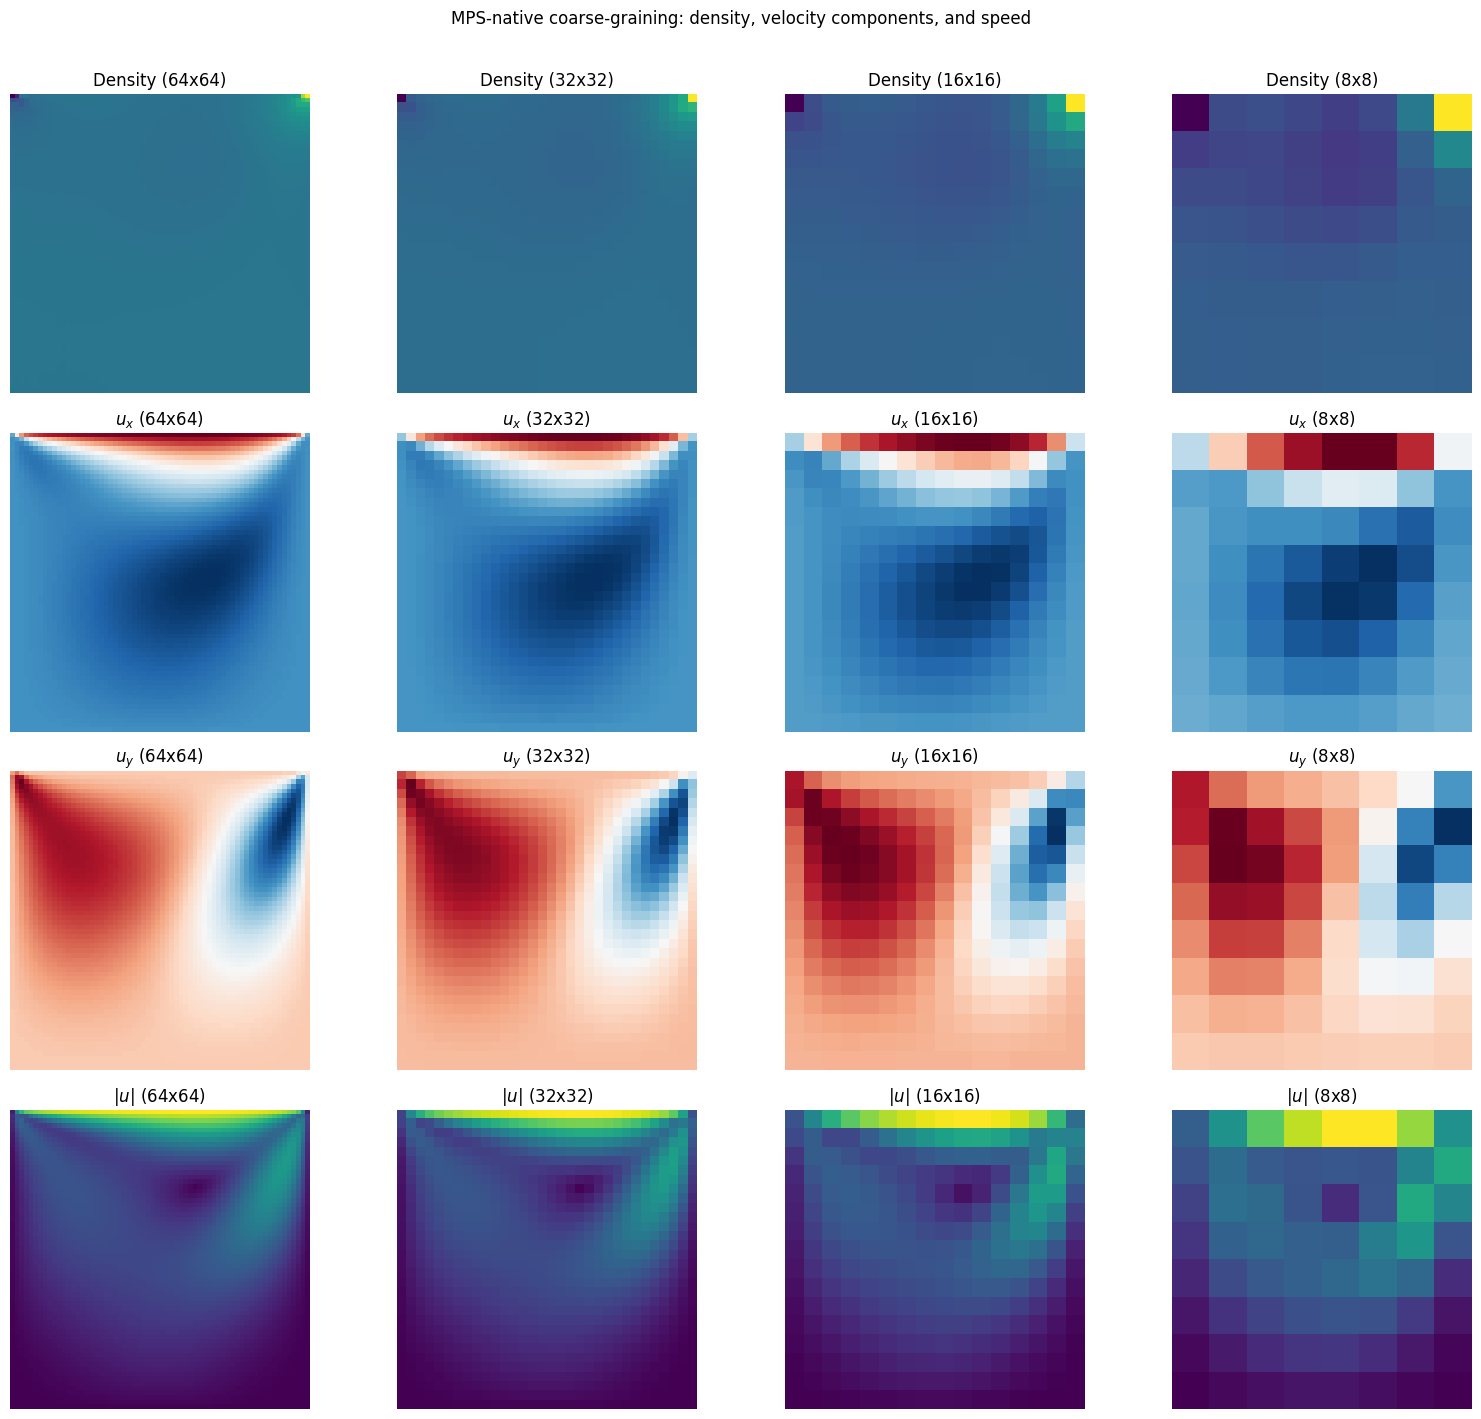

Coarse field validation (max error vs dense reshape+sum):
  rho level=1 (32x32): err=5.33e-15
  rho level=2 (16x16): err=1.78e-14
  rho level=3 (8x8): err=5.68e-14
  ux level=1 (32x32): err=2.22e-16
  ux level=2 (16x16): err=1.55e-15
  ux level=3 (8x8): err=2.22e-15
  uy level=1 (32x32): err=1.11e-16
  uy level=2 (16x16): err=4.44e-16
  uy level=3 (8x8): err=1.55e-15


In [10]:
# Coarse-grain VELOCITY fields (not just density)
from tn_lbm.collision import compute_moments_mps, compute_inverse_density_mps, build_ones_mps
from tn_lbm.arithmetic import mps_sum_value

# Compute velocity MPS: ux = rhou_x * (1/rho)
rho_mps, rhou_x_mps, rhou_y_mps = compute_moments_mps(mps_list, D2Q9, max_bond=64)
ones = build_ones_mps(len(mps_list[0].tensors))
inv_rho_mps = compute_inverse_density_mps(rho_mps, ones, n, max_bond=64)

from tn_lbm.arithmetic import mps_hadamard
ux_mps = mps_hadamard(rhou_x_mps, inv_rho_mps, max_bond=64)
uy_mps = mps_hadamard(rhou_y_mps, inv_rho_mps, max_bond=64)

# Coarse fields at different levels
from tn.compression import qtt_to_field

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

fields = [
    (rho_mps, 'Density', 'viridis', None),
    (ux_mps, '$u_x$', 'RdBu_r', None),
    (uy_mps, '$u_y$', 'RdBu_r', None),
]

# Rows 0-2: density, ux, uy
for row, (field_mps, field_name, cmap, _) in enumerate(fields):
    full = qtt_to_field(field_mps, meta)
    axes[row, 0].imshow(full.T, origin='lower', cmap=cmap)
    axes[row, 0].set_title(f'{field_name} ({n}x{n})'); axes[row, 0].axis('off')

    for col, level in enumerate([1, 2, 3]):
        coarse = mps_coarse_field(field_mps, meta, coarse_level=level)
        n_c = n // (2**level)
        axes[row, col+1].imshow(coarse.T, origin='lower', cmap=cmap)
        axes[row, col+1].set_title(f'{field_name} ({n_c}x{n_c})'); axes[row, col+1].axis('off')

# Row 3: speed |u| = sqrt(ux^2 + uy^2)
ux_full = qtt_to_field(ux_mps, meta)
uy_full = qtt_to_field(uy_mps, meta)
speed_full = np.sqrt(ux_full**2 + uy_full**2)
axes[3, 0].imshow(speed_full.T, origin='lower', cmap='viridis')
axes[3, 0].set_title(f'$|u|$ ({n}x{n})'); axes[3, 0].axis('off')

for col, level in enumerate([1, 2, 3]):
    ux_c = mps_coarse_field(ux_mps, meta, coarse_level=level)
    uy_c = mps_coarse_field(uy_mps, meta, coarse_level=level)
    n_c = n // (2**level)
    block = 2**level
    # Speed from coarse velocities (divide by block^2 to get average, not sum)
    speed_c = np.sqrt((ux_c / block**2)**2 + (uy_c / block**2)**2)
    axes[3, col+1].imshow(speed_c.T, origin='lower', cmap='viridis')
    axes[3, col+1].set_title(f'$|u|$ ({n_c}x{n_c})'); axes[3, col+1].axis('off')

plt.suptitle('MPS-native coarse-graining: density, velocity components, and speed', y=1.01)
plt.tight_layout()
plt.show()

# Validation: coarse vs dense reference
print("Coarse field validation (max error vs dense reshape+sum):")
for field_mps, name in [(rho_mps, 'rho'), (ux_mps, 'ux'), (uy_mps, 'uy')]:
    full = qtt_to_field(field_mps, meta)
    for level in [1, 2, 3]:
        coarse = mps_coarse_field(field_mps, meta, coarse_level=level)
        n_c = n // (2**level)
        block = 2**level
        dense_coarse = full.reshape(n_c, block, n_c, block).sum(axis=(1, 3))
        err = np.max(np.abs(coarse - dense_coarse))
        print(f"  {name} level={level} ({n_c}x{n_c}): err={err:.2e}")

## 4. End-to-End MPS-Native Simulation

Complete workflow with NO decompression in the loop:
```
init -> collide_mps -> stream+BC_mps -> check_convergence_mps -> extract observables_mps
```

The dense field is NEVER materialized during simulation. Only decompressed at the very end for visualization.

In [ ]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])
mapping = 'snake'
max_bond = 64
conv_tol = 1e-5
max_nt = 10000

# Setup (MPS from the start)
bc_data = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)
f_init = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
mps_pops, meta = compress_populations(f_init, mapping=mapping)
mps_pops_old = [m.copy() for m in mps_pops]

history = {'t': [], 'du': [], 'mass': [], 'mean_chi': []}
t_converged = None
consec_count = 0

print(f"End-to-end MPS-native LBM ({n}x{n}, Re={Re}, max_bond={max_bond})")
print("No decompression in the loop!")
print("=" * 60)
t_start = time.time()

for t in range(max_nt):
    # --- MPS collision (no dense) ---
    mps_pops = collide_bgk_mps(mps_pops, D2Q9, tau, n, max_bond=max_bond)
    
    # --- MPS stream + BC (no dense) ---
    mps_pops = apply_mps_boundary(mps_pops, D2Q9, bc_data, max_bond=max_bond)
    
    # --- MPS convergence check (no dense!) ---
    if t % 100 == 0 and t > 0:
        converged, du = check_convergence_mps(mps_pops, mps_pops_old, tol=conv_tol)
        
        # MPS-native mass check
        mass = sum(mps_sum_value(mps_pops[i]) for i in range(9))
        mean_chi = np.mean([m.max_bond() for m in mps_pops])
        
        history['t'].append(t)
        history['du'].append(du)
        history['mass'].append(mass)
        history['mean_chi'].append(mean_chi)
        
        consec_count = consec_count + 1 if du < conv_tol else 0
        if t_converged is None and consec_count >= 2:
            t_converged = t
            print(f"  Converged at t={t} (du={du:.2e})")
    
    # Save for next convergence check
    if t % 100 == 99:
        mps_pops_old = [m.copy() for m in mps_pops]
    
    if t % 1000 == 0 and t > 0 and history['du']:
        print(f"  t={t}: du={history['du'][-1]:.2e}, chi={history['mean_chi'][-1]:.1f}, "
              f"mass={history['mass'][-1]:.2f}")
    
    if t_converged is not None:
        break

elapsed = time.time() - t_start
print(f"\nFinished in {elapsed:.0f}s ({t+1} steps).")
print(f"Converged: {'yes at t=' + str(t_converged) if t_converged else 'no'}")

End-to-end MPS-native LBM (64x64, Re=100, max_bond=64)
No decompression in the loop!
  t=1000: du=4.45e-05, chi=13.2, mass=4096.00


In [21]:
# --- Extract final observables from MPS (no decompression!) ---
print("Extracting observables from MPS (no decompression):")
print("=" * 60)

# Mass
final_mass = sum(mps_sum_value(mps_pops[i]) for i in range(9))
print(f"Total mass: {final_mass:.4f} (initial: {n*n:.0f})")

# Centerline velocity at selected Ghia points
print(f"\nCenterline ux/u_lid at x={n//2}:")
mid_x = n // 2
ux_mps_points = []
for ghia_y in GHIA_Y:
    y_idx = min(int(round(ghia_y * (n - 1))), n - 1)
    rho_pt = sum(mps_evaluate_at_point(mps_pops[i], mid_x, y_idx, n, meta) for i in range(9))
    rhou_x_pt = sum(D2Q9.c[i, 0] * mps_evaluate_at_point(mps_pops[i], mid_x, y_idx, n, meta)
                    for i in range(9))
    ux_mps_points.append((rhou_x_pt / rho_pt) / u_lid)

rms_e2e = np.sqrt(np.mean((np.array(ux_mps_points) - GHIA_U_RE100)**2))
print(f"  RMS vs Ghia: {rms_e2e:.6f}")

# Bond dimension
mean_chi = np.mean([m.max_bond() for m in mps_pops])
print(f"  Mean chi: {mean_chi:.1f}")

Extracting observables from MPS (no decompression):
Total mass: 4096.0049 (initial: 4096)

Centerline ux/u_lid at x=32:
  RMS vs Ghia: 0.019164
  Mean chi: 13.6


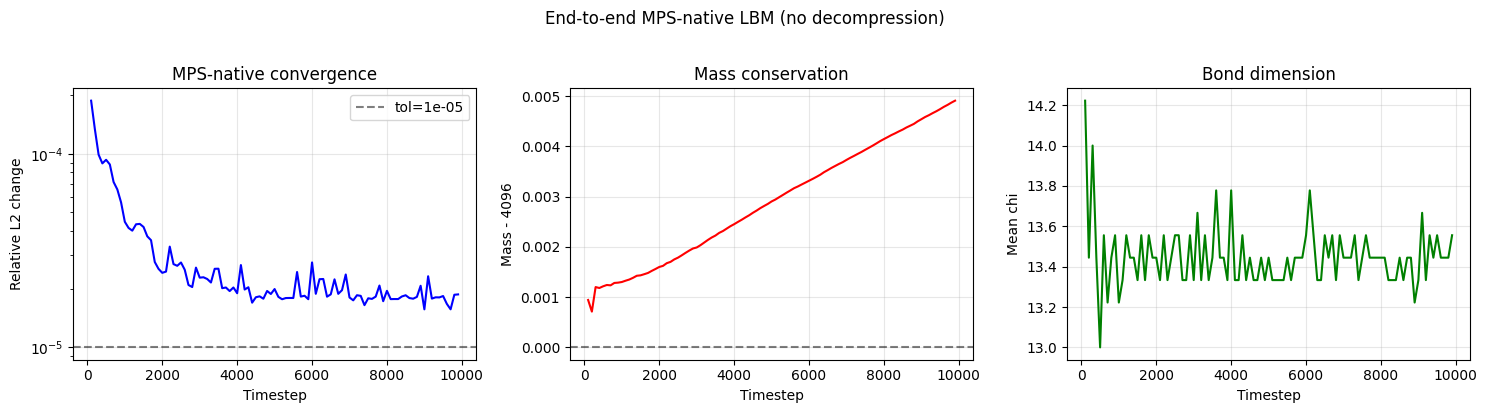

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Convergence
axes[0].semilogy(history['t'], history['du'], 'b-')
axes[0].axhline(conv_tol, color='k', linestyle='--', alpha=0.5, label=f'tol={conv_tol}')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Relative L2 change')
axes[0].set_title('MPS-native convergence'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Mass drift
mass_drift = np.array(history['mass']) - n*n
axes[1].plot(history['t'], mass_drift, 'r-')
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel(f'Mass - {n*n}')
axes[1].set_title('Mass conservation'); axes[1].grid(True, alpha=0.3)

# Chi
axes[2].plot(history['t'], history['mean_chi'], 'g-')
axes[2].set_xlabel('Timestep'); axes[2].set_ylabel('Mean chi')
axes[2].set_title('Bond dimension'); axes[2].grid(True, alpha=0.3)

plt.suptitle('End-to-end MPS-native LBM (no decompression)', y=1.02)
plt.tight_layout()
plt.show()

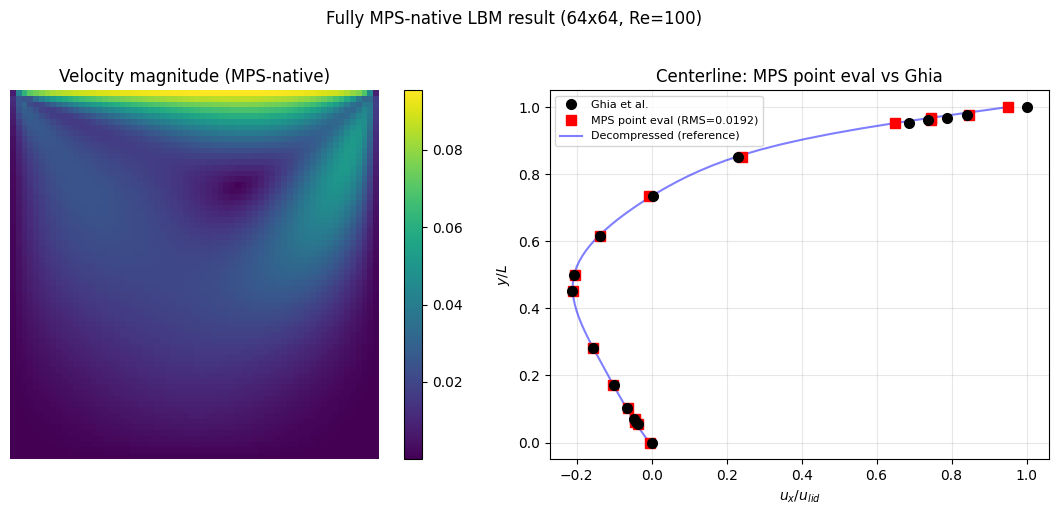

Summary:
  Simulation: 9901 steps, 8703s, fully MPS-native
  Convergence: du=1.88e-05
  Mass: 4096.0049 (drift: 4.94e-03)
  Bond dimension: 13.6
  Ghia RMS (from MPS point eval): 0.019164


In [23]:
# Final visualization: decompress ONLY for the plot (not part of the simulation)
f_final = decompress_populations(mps_pops, meta)
_, u_final = compute_moments(D2Q9, f_final)
speed = np.sqrt(u_final[0]**2 + u_final[1]**2)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

im = axes[0].imshow(speed.T, origin='lower', cmap='viridis')
axes[0].set_title('Velocity magnitude (MPS-native)'); plt.colorbar(im, ax=axes[0])
axes[0].axis('off')

axes[1].plot(GHIA_U_RE100, GHIA_Y, 'ko', markersize=7, label='Ghia et al.', zorder=5)
axes[1].plot(np.array(ux_mps_points), GHIA_Y, 'rs', markersize=7,
             label=f'MPS point eval (RMS={rms_e2e:.4f})', zorder=4)
axes[1].plot(u_final[0, mid_x, :]/u_lid, np.linspace(0,1,n), 'b-', linewidth=1.5,
             alpha=0.5, label='Decompressed (reference)')
axes[1].set_xlabel('$u_x / u_{lid}$'); axes[1].set_ylabel('$y / L$')
axes[1].set_title('Centerline: MPS point eval vs Ghia')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Fully MPS-native LBM result ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

print(f"Summary:")
print(f"  Simulation: {t+1} steps, {elapsed:.0f}s, fully MPS-native")
print(f"  Convergence: du={history['du'][-1]:.2e}")
print(f"  Mass: {final_mass:.4f} (drift: {final_mass - n*n:.2e})")
print(f"  Bond dimension: {mean_chi:.1f}")
print(f"  Ghia RMS (from MPS point eval): {rms_e2e:.6f}")

## 5. Mass Conservation Comparison

Compare mass drift of vanilla HWBB, vanilla FWBB, and MPS-native over time. Vanilla runs are fast (dense operations only). MPS mass uses data from the end-to-end run above.

Mass conservation experiment (16x16, Re=100)
Running HWBB to convergence...
Running FWBB to convergence...
  Converged at t=3247 (du=9.68e-07)
Running MPS-native for 3247 steps (max_bond=16, cutoff=0)...
  t=1000, elapsed=329s
  t=2000, elapsed=658s
  t=3000, elapsed=987s
  Done in 1068s.


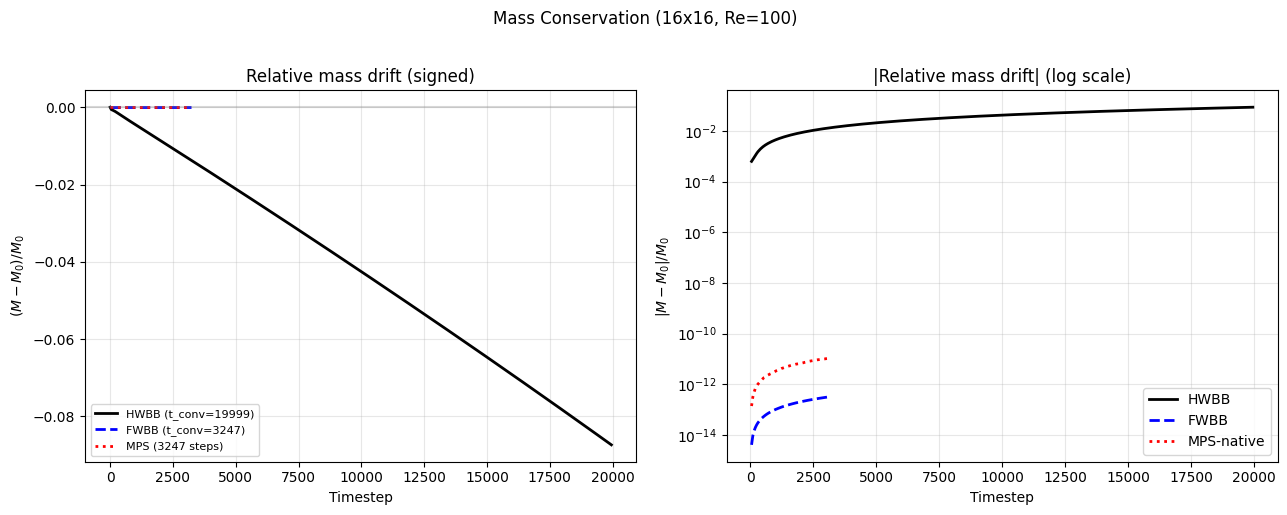


Final mass drift:
  Method          |  Steps |     Absolute |     Relative |          %
  --------------------------------------------------------------
  HWBB            |  19999 |   -22.360410 |    -8.73e-02 | 8.734535%
  FWBB            |   3247 |    -0.000000 |    -3.22e-13 | 0.000000%
  MPS-native      |   3247 |    +0.000000 |     1.06e-11 | 0.000000%


In [3]:
# Mass conservation: HWBB vs FWBB vs MPS-native (fair comparison)
# Each vanilla runs to its own convergence. MPS runs for FWBB's convergence time.
# MPS uses max_bond=full_rank, cutoff=0 — no truncation.
n_m = 16; Re_m = 100; u_lid_m = 0.1
nu_m = u_lid_m * n_m / Re_m; tau_m = 3*nu_m + 0.5
walls_m, lid_m = create_cavity_walls(n_m)
u_wall_m = np.array([u_lid_m, 0.0])
initial_mass = float(n_m * n_m)
max_bond_m = n_m  # full rank
cutoff_m = 0      # no SVD truncation
conv_tol_m = 1e-6

print(f"Mass conservation experiment ({n_m}x{n_m}, Re={Re_m})")
print("=" * 60)

# --- HWBB to convergence ---
print("Running HWBB to convergence...")
f_h = compute_equilibrium(D2Q9, np.ones((n_m,n_m)), np.zeros((2,n_m,n_m)))
u_prev_h = np.zeros((2,n_m,n_m)); consec_h = 0
mass_h = {'t': [], 'abs': [], 'rel': []}
for t in range(20000):
    f_h = collide_bgk(D2Q9, f_h, tau_m)
    f_h = stream(D2Q9, f_h)
    f_h = apply_bounce_back(D2Q9, f_h, walls_m)
    f_h = apply_bounce_back_moving_top(D2Q9, f_h, u_wall_m)
    _, u_vh = compute_moments(D2Q9, f_h)
    du_h = np.sqrt(np.sum((u_vh - u_prev_h)**2) / (np.sum(u_vh**2) + 1e-30))
    u_prev_h = u_vh.copy()
    consec_h = consec_h + 1 if (t > 0 and du_h < conv_tol_m) else 0
    if t % 50 == 0:
        m = np.sum(compute_moments(D2Q9, f_h)[0])
        mass_h['t'].append(t); mass_h['abs'].append(m - initial_mass)
        mass_h['rel'].append((m - initial_mass) / initial_mass)
    if consec_h >= 2:
        print(f"  Converged at t={t} (du={du_h:.2e})")
        break
t_conv_h = t

# --- FWBB to convergence ---
print("Running FWBB to convergence...")
f_f = compute_equilibrium(D2Q9, np.ones((n_m,n_m)), np.zeros((2,n_m,n_m)))
u_prev_f = np.zeros((2,n_m,n_m)); consec_f = 0
mass_f = {'t': [], 'abs': [], 'rel': []}
for t in range(20000):
    f_f = collide_bgk(D2Q9, f_f, tau_m)
    f_f = apply_fwbb(D2Q9, f_f, lid_m, u_wall_m)
    _, u_vf = compute_moments(D2Q9, f_f)
    du_f = np.sqrt(np.sum((u_vf - u_prev_f)**2) / (np.sum(u_vf**2) + 1e-30))
    u_prev_f = u_vf.copy()
    consec_f = consec_f + 1 if (t > 0 and du_f < conv_tol_m) else 0
    if t % 50 == 0:
        m = np.sum(compute_moments(D2Q9, f_f)[0])
        mass_f['t'].append(t); mass_f['abs'].append(m - initial_mass)
        mass_f['rel'].append((m - initial_mass) / initial_mass)
    if consec_f >= 2:
        print(f"  Converged at t={t} (du={du_f:.2e})")
        break
t_conv_f = t

# --- MPS-native for FWBB convergence time ---
print(f"Running MPS-native for {t_conv_f} steps (max_bond={max_bond_m}, cutoff={cutoff_m})...")
from tn_lbm.arithmetic import mps_sum_value
bc_data_m = precompute_cavity_bc(n_m, D2Q9, u_wall_m, mapping='snake')
mps_m, meta_m = compress_populations(
    compute_equilibrium(D2Q9, np.ones((n_m,n_m)), np.zeros((2,n_m,n_m))), mapping='snake')
mass_mps = {'t': [], 'abs': [], 'rel': []}
t0 = time.time()
for t in range(t_conv_f + 1):
    if t > 0:
        mps_m = collide_bgk_mps(mps_m, D2Q9, tau_m, n_m,
                                 max_bond=max_bond_m, cutoff=cutoff_m)
        mps_m = apply_mps_boundary(mps_m, D2Q9, bc_data_m,
                                    max_bond=max_bond_m, cutoff=cutoff_m)
    if t % 50 == 0:
        m = sum(mps_sum_value(mps_m[i]) for i in range(9))
        mass_mps['t'].append(t); mass_mps['abs'].append(m - initial_mass)
        mass_mps['rel'].append((m - initial_mass) / initial_mass)
    if t % 1000 == 0 and t > 0:
        print(f"  t={t}, elapsed={time.time()-t0:.0f}s")
print(f"  Done in {time.time()-t0:.0f}s.")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(mass_h['t'], mass_h['rel'], 'k-', linewidth=2, label=f'HWBB (t_conv={t_conv_h})')
ax.plot(mass_f['t'], mass_f['rel'], 'b--', linewidth=2, label=f'FWBB (t_conv={t_conv_f})')
ax.plot(mass_mps['t'], mass_mps['rel'], 'r:', linewidth=2, label=f'MPS ({t_conv_f} steps)')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Timestep'); ax.set_ylabel('$(M - M_0) / M_0$')
ax.set_title('Relative mass drift (signed)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
rd_h = [abs(r) for r in mass_h['rel'][1:]]
rd_f = [max(abs(r), 1e-16) for r in mass_f['rel'][1:]]
rd_m = [max(abs(r), 1e-16) for r in mass_mps['rel'][1:]]
ax.semilogy(mass_h['t'][1:], rd_h, 'k-', linewidth=2, label='HWBB')
ax.semilogy(mass_f['t'][1:], rd_f, 'b--', linewidth=2, label='FWBB')
ax.semilogy(mass_mps['t'][1:], rd_m, 'r:', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('$|M - M_0| / M_0$')
ax.set_title('|Relative mass drift| (log scale)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Mass Conservation ({n_m}x{n_m}, Re={Re_m})', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFinal mass drift:")
print(f"  {'Method':15} | {'Steps':>6} | {'Absolute':>12} | {'Relative':>12} | {'%':>10}")
print(f"  {'-'*62}")
print(f"  {'HWBB':15} | {t_conv_h:>6} | {mass_h['abs'][-1]:>+12.6f} | {mass_h['rel'][-1]:>12.2e} | {abs(mass_h['rel'][-1])*100:.6f}%")
print(f"  {'FWBB':15} | {t_conv_f:>6} | {mass_f['abs'][-1]:>+12.6f} | {mass_f['rel'][-1]:>12.2e} | {abs(mass_f['rel'][-1])*100:.6f}%")
print(f"  {'MPS-native':15} | {t_conv_f:>6} | {mass_mps['abs'][-1]:>+12.6f} | {mass_mps['rel'][-1]:>12.2e} | {abs(mass_mps['rel'][-1])*100:.6f}%")

Running HWBB and FWBB for 20000 steps...
  t=5000
  t=10000
  t=15000
  t=20000
Done.



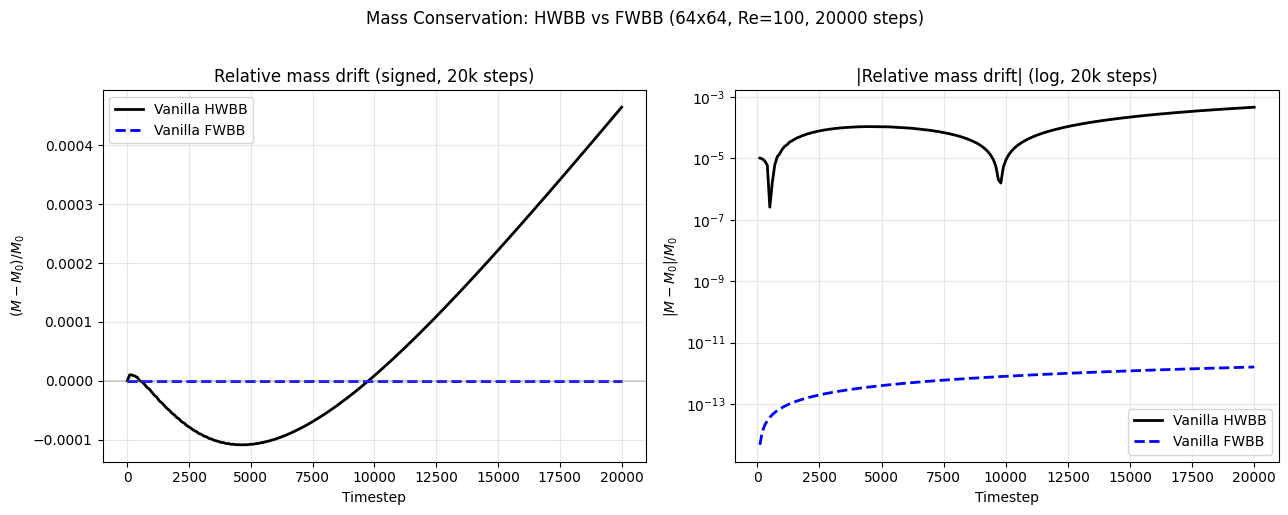

Final after 20000 steps:
  HWBB: rel=4.65e-04
  FWBB: rel=-1.60e-12


In [24]:
# Extended mass tracking: HWBB vs FWBB for 20k steps (no MPS, fast)
nt_ext = 20000
print(f"Running HWBB and FWBB for {nt_ext} steps...")

f_hwbb_ext = compute_equilibrium(D2Q9, np.ones((n_mass,n_mass)), np.zeros((2,n_mass,n_mass)))
f_fwbb_ext = f_hwbb_ext.copy()
mass_hwbb_ext = {'t': [], 'rel': []}
mass_fwbb_ext = {'t': [], 'rel': []}

for t in range(nt_ext + 1):
    if t > 0:
        f_hwbb_ext = collide_bgk(D2Q9, f_hwbb_ext, tau_m)
        f_hwbb_ext = stream(D2Q9, f_hwbb_ext)
        f_hwbb_ext = apply_bounce_back(D2Q9, f_hwbb_ext, walls_m)
        f_hwbb_ext = apply_bounce_back_moving_top(D2Q9, f_hwbb_ext, u_wall_m)

        f_fwbb_ext = collide_bgk(D2Q9, f_fwbb_ext, tau_m)
        f_fwbb_ext = apply_fwbb(D2Q9, f_fwbb_ext, lid_m, u_wall_m)

    if t % 100 == 0:
        m_h = np.sum(compute_moments(D2Q9, f_hwbb_ext)[0])
        m_f = np.sum(compute_moments(D2Q9, f_fwbb_ext)[0])
        mass_hwbb_ext['t'].append(t)
        mass_hwbb_ext['rel'].append((m_h - initial_mass) / initial_mass)
        mass_fwbb_ext['t'].append(t)
        mass_fwbb_ext['rel'].append((m_f - initial_mass) / initial_mass)

    if t % 5000 == 0 and t > 0:
        print(f"  t={t}")

print("Done.\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(mass_hwbb_ext['t'], mass_hwbb_ext['rel'], 'k-', linewidth=2, label='Vanilla HWBB')
ax.plot(mass_fwbb_ext['t'], mass_fwbb_ext['rel'], 'b--', linewidth=2, label='Vanilla FWBB')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Timestep'); ax.set_ylabel('$(M - M_0) / M_0$')
ax.set_title('Relative mass drift (signed, 20k steps)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
t_h = mass_hwbb_ext['t'][1:]; rd_h = [abs(r) for r in mass_hwbb_ext['rel'][1:]]
t_f = mass_fwbb_ext['t'][1:]; rd_f = [max(abs(r), 1e-16) for r in mass_fwbb_ext['rel'][1:]]
ax.semilogy(t_h, rd_h, 'k-', linewidth=2, label='Vanilla HWBB')
ax.semilogy(t_f, rd_f, 'b--', linewidth=2, label='Vanilla FWBB')
ax.set_xlabel('Timestep'); ax.set_ylabel('$|M - M_0| / M_0$')
ax.set_title('|Relative mass drift| (log, 20k steps)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Mass Conservation: HWBB vs FWBB ({n_mass}x{n_mass}, Re={Re_mass}, {nt_ext} steps)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Final after {nt_ext} steps:")
print(f"  HWBB: rel={mass_hwbb_ext['rel'][-1]:.2e}")
print(f"  FWBB: rel={mass_fwbb_ext['rel'][-1]:.2e}")

## 5b. Velocity Field Comparison: FWBB vs MPS-native

Direct L2 comparison of the converged velocity fields from Section 5. Since both use the same BC (FWBB), any difference is purely from the MPS tensor arithmetic.

FWBB vs MPS-native velocity comparison (64x64, Re=100):
  Relative L2 error: 2.27e-05
  Max pointwise error: 7.24e-06
  (This difference is purely from MPS tensor arithmetic — same BC formulation)


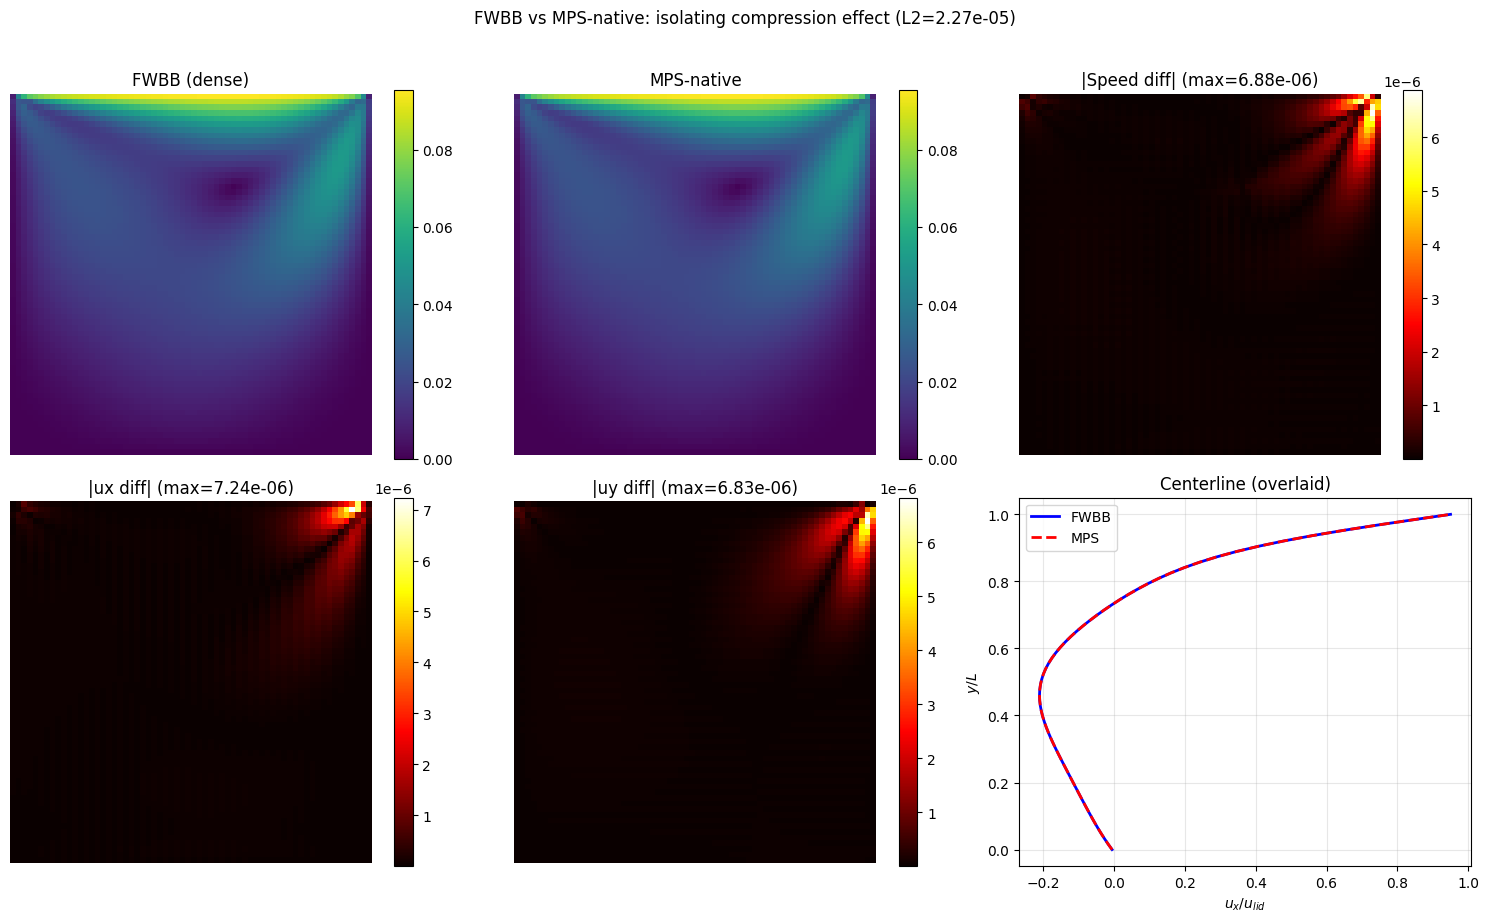

In [5]:
# Use the converged fields from Section 5 mass experiment
# f_f = dense FWBB converged, mps_m = MPS-native at same steps
_, u_fwbb_64 = compute_moments(D2Q9, f_f)
f_mps_64 = decompress_populations(mps_m, meta_m)
_, u_mps_64 = compute_moments(D2Q9, f_mps_64)

# L2 relative error between FWBB and MPS
u_diff = np.sqrt((u_fwbb_64[0] - u_mps_64[0])**2 + (u_fwbb_64[1] - u_mps_64[1])**2)
u_ref = np.sqrt(u_fwbb_64[0]**2 + u_fwbb_64[1]**2)
l2_rel = np.linalg.norm(u_diff) / (np.linalg.norm(u_ref) + 1e-30)
max_err = np.max(np.abs(u_fwbb_64 - u_mps_64))

print(f"FWBB vs MPS-native velocity comparison ({n_m}x{n_m}, Re={Re_m}):")
print(f"  Relative L2 error: {l2_rel:.2e}")
print(f"  Max pointwise error: {max_err:.2e}")
print(f"  (This difference is purely from MPS tensor arithmetic — same BC formulation)")

# Velocity fields + difference
speed_fwbb = np.sqrt(u_fwbb_64[0]**2 + u_fwbb_64[1]**2)
speed_mps = np.sqrt(u_mps_64[0]**2 + u_mps_64[1]**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
vmax = max(speed_fwbb.max(), speed_mps.max())

# Top row: speed fields + difference
im0 = axes[0,0].imshow(speed_fwbb.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[0,0].set_title('FWBB (dense)'); plt.colorbar(im0, ax=axes[0,0]); axes[0,0].axis('off')

im1 = axes[0,1].imshow(speed_mps.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[0,1].set_title('MPS-native'); plt.colorbar(im1, ax=axes[0,1]); axes[0,1].axis('off')

im2 = axes[0,2].imshow(np.abs(speed_fwbb - speed_mps).T, origin='lower', cmap='hot')
axes[0,2].set_title(f'|Speed diff| (max={np.max(np.abs(speed_fwbb - speed_mps)):.2e})')
plt.colorbar(im2, ax=axes[0,2]); axes[0,2].axis('off')

# Bottom row: ux, uy, pointwise error map
im3 = axes[1,0].imshow(np.abs(u_fwbb_64[0] - u_mps_64[0]).T, origin='lower', cmap='hot')
axes[1,0].set_title(f'|ux diff| (max={np.max(np.abs(u_fwbb_64[0] - u_mps_64[0])):.2e})')
plt.colorbar(im3, ax=axes[1,0]); axes[1,0].axis('off')

im4 = axes[1,1].imshow(np.abs(u_fwbb_64[1] - u_mps_64[1]).T, origin='lower', cmap='hot')
axes[1,1].set_title(f'|uy diff| (max={np.max(np.abs(u_fwbb_64[1] - u_mps_64[1])):.2e})')
plt.colorbar(im4, ax=axes[1,1]); axes[1,1].axis('off')

# Centerline comparison
mid = n_m // 2
y_coords = np.linspace(0, 1, n_m)
axes[1,2].plot(u_fwbb_64[0, mid, :] / u_lid_m, y_coords, 'b-', linewidth=2, label='FWBB')
axes[1,2].plot(u_mps_64[0, mid, :] / u_lid_m, y_coords, 'r--', linewidth=2, label='MPS')
axes[1,2].set_xlabel('$u_x / u_{lid}$'); axes[1,2].set_ylabel('$y / L$')
axes[1,2].set_title('Centerline (overlaid)'); axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3)

plt.suptitle(f'FWBB vs MPS-native: isolating compression effect (L2={l2_rel:.2e})', y=1.02)
plt.tight_layout()
plt.show()

## 6. Convergence Verification (16x16, no truncation)

Verify that MPS-native LBM converges at the same rate as vanilla FWBB when there's no bond dimension truncation (max_bond=None). Small grid for fast execution.

Vanilla FWBB (16x16, Re=100, L2 velocity, tol=1e-06):
  t=0, du=1.00e+00
  t=1000, du=4.52e-04
  t=2000, du=2.65e-05
  t=3000, du=4.97e-06
  Converged at t=3247 (du=9.68e-07)

MPS-native (16x16, max_bond=16, cutoff=0, tol=1e-06):
  t=1000, du=4.88e-04, chi=16.0, elapsed=4312s
  t=2000, du=2.52e-05, chi=16.0, elapsed=4645s
  t=3000, du=1.62e-05, chi=16.0, elapsed=4977s

Result:
  Vanilla FWBB:  converged at t=3247
  MPS-native:    NOT converged
  MPS runtime:   5059s
  Final MPS chi: 16.0


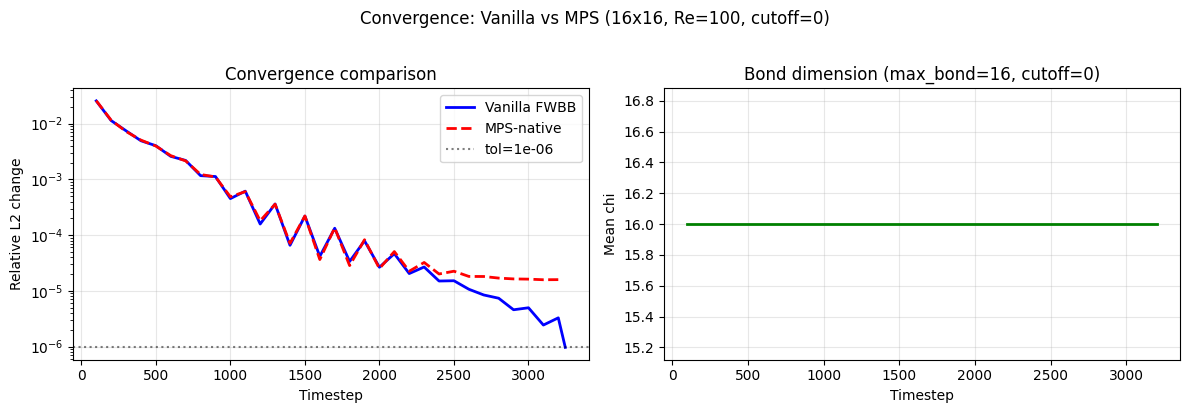

In [2]:
n_s = 16; Re_s = 100; u_lid_s = 0.1
nu_s = u_lid_s * n_s / Re_s; tau_s = 3*nu_s + 0.5
walls_s, lid_s = create_cavity_walls(n_s)
u_wall_s = np.array([u_lid_s, 0.0])
conv_tol_s = 1e-6; max_nt_s = 10000
max_bond_s = 16  # full rank for 16x16 grid
cutoff_s = 0     # NO cutoff — keep all singular values up to max_bond

# --- Step 1: Vanilla FWBB to convergence ---
print(f"Vanilla FWBB ({n_s}x{n_s}, Re={Re_s}, L2 velocity, tol={conv_tol_s}):")
f_van_s = compute_equilibrium(D2Q9, np.ones((n_s,n_s)), np.zeros((2,n_s,n_s)))
u_prev_s = np.zeros((2,n_s,n_s)); consec_s = 0; t_conv_s = max_nt_s
du_van_hist = {'t': [], 'du': []}

for t in range(max_nt_s):
    f_van_s = collide_bgk(D2Q9, f_van_s, tau_s)
    f_van_s = apply_fwbb(D2Q9, f_van_s, lid_s, u_wall_s)
    _, u_vs = compute_moments(D2Q9, f_van_s)
    du_s = np.sqrt(np.sum((u_vs - u_prev_s)**2) / (np.sum(u_vs**2) + 1e-30))
    u_prev_s = u_vs.copy()
    consec_s = consec_s + 1 if (t > 0 and du_s < conv_tol_s) else 0
    if t % 100 == 0 and t > 0:
        du_van_hist['t'].append(t); du_van_hist['du'].append(du_s)
    if consec_s >= 2:
        t_conv_s = t
        du_van_hist['t'].append(t); du_van_hist['du'].append(du_s)
        print(f"  Converged at t={t} (du={du_s:.2e})")
        break
    if t % 1000 == 0: print(f"  t={t}, du={du_s:.2e}")

# --- Step 2: MPS-native, max_bond=full rank, cutoff=0 ---
print(f"\nMPS-native ({n_s}x{n_s}, max_bond={max_bond_s}, cutoff={cutoff_s}, tol={conv_tol_s}):")
bc_data_s = precompute_cavity_bc(n_s, D2Q9, u_wall_s, mapping='snake')
mps_s, meta_s = compress_populations(
    compute_equilibrium(D2Q9, np.ones((n_s,n_s)), np.zeros((2,n_s,n_s))), mapping='snake')
moments_old_s = None; consec_ms = 0; t_conv_ms = None
du_mps_hist = {'t': [], 'du': [], 'chi': []}
t0 = time.time()

for t in range(t_conv_s + 1):
    mps_s, moments_new_s = collide_bgk_mps(mps_s, D2Q9, tau_s, n_s,
                                             max_bond=max_bond_s, cutoff=cutoff_s,
                                             return_moments=True)
    mps_s = apply_mps_boundary(mps_s, D2Q9, bc_data_s,
                                max_bond=max_bond_s, cutoff=cutoff_s)

    if moments_old_s is not None:
        _, du_ms = check_convergence_mps(
            mps_s, None, tol=conv_tol_s, mode='velocity',
            moments_new=moments_new_s, moments_old=moments_old_s)
        consec_ms = consec_ms + 1 if du_ms < conv_tol_s else 0
        if t_conv_ms is None and consec_ms >= 2:
            t_conv_ms = t
            print(f"  Converged at t={t} (du={du_ms:.2e})")
        if t % 100 == 0:
            mean_chi = np.mean([m.max_bond() for m in mps_s])
            du_mps_hist['t'].append(t); du_mps_hist['du'].append(du_ms)
            du_mps_hist['chi'].append(mean_chi)
    else:
        du_ms = float('nan')

    moments_old_s = moments_new_s
    if t % 1000 == 0 and t > 0:
        mean_chi = np.mean([m.max_bond() for m in mps_s])
        print(f"  t={t}, du={du_ms:.2e}, chi={mean_chi:.1f}, elapsed={time.time()-t0:.0f}s")

elapsed_s = time.time() - t0
print(f"\nResult:")
print(f"  Vanilla FWBB:  converged at t={t_conv_s}")
print(f"  MPS-native:    {'converged at t=' + str(t_conv_ms) if t_conv_ms else 'NOT converged'}")
print(f"  MPS runtime:   {elapsed_s:.0f}s")
if du_mps_hist['chi']:
    print(f"  Final MPS chi: {du_mps_hist['chi'][-1]:.1f}")

# Plot du comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(du_van_hist['t'], du_van_hist['du'], 'b-', linewidth=2, label='Vanilla FWBB')
if du_mps_hist['t']:
    ax.semilogy(du_mps_hist['t'], du_mps_hist['du'], 'r--', linewidth=2, label='MPS-native')
ax.axhline(conv_tol_s, color='k', linestyle=':', alpha=0.5, label=f'tol={conv_tol_s}')
ax.set_xlabel('Timestep'); ax.set_ylabel('Relative L2 change')
ax.set_title('Convergence comparison'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
if du_mps_hist['t']:
    ax.plot(du_mps_hist['t'], du_mps_hist['chi'], 'g-', linewidth=2)
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean chi')
ax.set_title(f'Bond dimension (max_bond={max_bond_s}, cutoff={cutoff_s})'); ax.grid(True, alpha=0.3)

plt.suptitle(f'Convergence: Vanilla vs MPS ({n_s}x{n_s}, Re={Re_s}, cutoff={cutoff_s})', y=1.02)
plt.tight_layout()
plt.show()